## Домашнее задание – 4 (Использование DEER)

### Задача:
Изучить архитектуру DEER (Label-Guided In-Context Learning for Named Entity Recognition) и проверить ее эффективность на собственных данных. В новой статье которую разбирали (https://arxiv.org/abs/2505.23722) принята на EMNLP-25 в Main секцию (весь список тут (https://docs.google.com/spreadsheets/d/1V7EPtR8xq4kqUaShcGmm3wE-T1Ge730TA36Fkbz7jT8/edit?gid=0#gid=0)).

### Инструкция:
1. Определить вычислительную конфигурацию
2. Выбрать корпус (текстовый), какой хотим проверить
3. Применить DEER (можно свою реализацию или модификацию)
4. Построить графики/визуализации
5. Сделать заключение

### В итоге
- Код экспериментов (ноутбук или py с полным pipeline)
- Таблица и графики с результатами
- Выводы о том насколько DEER показал себя (хорошо или плохо)

In [1]:
import torch
import numpy as np
import pandas as pd
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import seaborn as sns
import re

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {device}")

CONFIG = {
    "lambda_1": 1.0,   # Weight for Token Score
    "lambda_2": 1.0,   # Weight for Embedding Score
    "w_e": 1.0,        # Weight for Entity Tokens
    "w_c": 1.0,        # Weight for Context Tokens
    "w_o": 0.01,       # Weight for Other Tokens
    "context_window": 2, # +/- 2 tokens around entity
    "top_k": 5,        # Number of shots to retrieve
    "subset_size": 1000 # To make this run fast for homework
}

/home/mitchell/dev/hse/HSE_DL_4_2025/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running on: cpu


In [2]:
print("Loading CoNLL-2003 dataset...")
dataset = load_dataset("BramVanroy/conll2003")

id2label = {
    0: "O", 1: "B-PER", 2: "I-PER", 3: "B-ORG", 4: "I-ORG", 
    5: "B-LOC", 6: "I-LOC", 7: "B-MISC", 8: "I-MISC"
}

def format_data(example):
    tokens = example['tokens']
    ner_tags = [id2label[tag] for tag in example['ner_tags']]
    return {"tokens": tokens, "ner_tags": ner_tags}

train_data = [format_data(x) for x in dataset['train'].select(range(CONFIG['subset_size']))]
test_data = [format_data(x) for x in dataset['test'].select(range(100))]

print(f"Loaded {len(train_data)} training samples and {len(test_data)} test samples.")
print("Example Sample:", train_data[0])

Loading CoNLL-2003 dataset...
Loaded 1000 training samples and 100 test samples.
Example Sample: {'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'ner_tags': ['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']}


In [3]:
class DEERStatistics:
    def __init__(self, context_window=2):
        self.context_window = context_window
        self.stats = defaultdict(lambda: {"E": 0, "C": 0, "O": 0})
        self.total_counts = {"E": 0, "C": 0, "O": 0}

    def _classify_tokens(self, tokens, tags):
        """
        Classifies tokens in a sentence as Entity (E), Context (C), or Other (O).
        """
        n = len(tokens)
        token_types = ["O"] * n        
        entity_indices = {i for i, tag in enumerate(tags) if tag != "O"}
        context_indices = set()
        for idx in entity_indices:
            start = max(0, idx - self.context_window)
            end = min(n, idx + self.context_window + 1)
            for c_idx in range(start, end):
                if c_idx not in entity_indices:
                    context_indices.add(c_idx)
        
        for i in range(n):
            if i in entity_indices:
                token_types[i] = "E"
            elif i in context_indices:
                token_types[i] = "C"
            else:
                token_types[i] = "O"
                
        return token_types

    def fit(self, data):
        print("Computing Label-Grounded Statistics...")
        for sample in data:
            tokens = sample['tokens']
            tags = sample['ner_tags']
            types = self._classify_tokens(tokens, tags)
            
            for token, t_type in zip(tokens, types):
                token_lower = token.lower()
                self.stats[token_lower][t_type] += 1
                self.total_counts[t_type] += 1
                
    def get_token_weight(self, token, config):
        """
        Calculates W(t) based on formula (3) in the paper
        """
        token = token.lower()
        counts = self.stats.get(token, {"E": 0, "C": 0, "O": 0})
        total_occurrences = sum(counts.values())
        
        if total_occurrences == 0:
            return config['w_o']

        p_e = counts['E'] / total_occurrences
        p_c = counts['C'] / total_occurrences
        p_o = counts['O'] / total_occurrences
        
        weight = (config['w_e'] * p_e) + (config['w_c'] * p_c) + (config['w_o'] * p_o)
        return weight

deer_stats = DEERStatistics(context_window=CONFIG['context_window'])
deer_stats.fit(train_data)

print(f"Stats computed. Example weight for 'London': {deer_stats.get_token_weight('London', CONFIG):.4f}")
print(f"Stats computed. Example weight for 'the': {deer_stats.get_token_weight('the', CONFIG):.4f}")

Computing Label-Grounded Statistics...
Stats computed. Example weight for 'London': 1.0000
Stats computed. Example weight for 'the': 0.4395


In [4]:
class DEERRetriever:
    def __init__(self, train_data, stats_model, config):
        self.train_data = train_data
        self.stats_model = stats_model
        self.config = config
        
        print("Encoding training data embeddings...")
        self.encoder = SentenceTransformer('all-MiniLM-L6-v2', device=device)
        self.train_sentences = [" ".join(x['tokens']) for x in train_data]
        self.train_embeddings = self.encoder.encode(self.train_sentences, convert_to_tensor=True)

    def compute_token_similarity(self, test_tokens, train_idx):
        """
        Computes S_token (Formula 2 in paper)
        """
        train_tokens_set = set([t.lower() for t in self.train_data[train_idx]['tokens']])
        score = 0
        
        for token in test_tokens:
            token_lower = token.lower()
            if token_lower in train_tokens_set:
                weight = self.stats_model.get_token_weight(token, self.config)
                score += weight
        return score

    def retrieve(self, test_sample, k=5):
        test_tokens = test_sample['tokens']
        test_sentence = " ".join(test_tokens)
        
        test_embedding = self.encoder.encode(test_sentence, convert_to_tensor=True)
        cos_scores = torch.nn.functional.cosine_similarity(test_embedding, self.train_embeddings)
        cos_scores = cos_scores.cpu().numpy()
        
        token_scores = []
        for i in range(len(self.train_data)):
            token_scores.append(self.compute_token_similarity(test_tokens, i))
        token_scores = np.array(token_scores)
        
        if token_scores.max() > 0:
            token_scores = token_scores / token_scores.max()
        
        final_scores = (self.config['lambda_1'] * token_scores) + \
                       (self.config['lambda_2'] * cos_scores)
        
        top_indices = np.argsort(final_scores)[::-1][:k]
        
        return [self.train_data[i] for i in top_indices]

retriever = DEERRetriever(train_data, deer_stats, CONFIG)

Encoding training data embeddings...


In [5]:
def evaluate_retrieval(test_set, retriever, k=5, method="DEER"):
    total_relevant = 0
    total_retrieved = 0
    
    # Baseline KATE (Sentence Embedding only)
    original_lambda1 = retriever.config['lambda_1']
    if method == "KATE":
        retriever.config['lambda_1'] = 0.0
    
    for sample in test_set:
        true_tags = set([t for t in sample['ner_tags'] if t != "O"])
        if not true_tags: continue

        examples = retriever.retrieve(sample, k=k)
        
        for ex in examples:
            ex_tags = set([t for t in ex['ner_tags'] if t != "O"])
            if not true_tags.isdisjoint(ex_tags):
                total_relevant += 1
            total_retrieved += 1
            
    retriever.config['lambda_1'] = original_lambda1
    
    return total_relevant / total_retrieved

# Run Evaluation
kate_score = evaluate_retrieval(test_data, retriever, k=5, method="KATE")
deer_score = evaluate_retrieval(test_data, retriever, k=5, method="DEER")

print(f"Retrieval Quality (Relevance of Retrieved Examples):")
print(f"KATE (Baseline): {kate_score:.4f}")
print(f"DEER:     {deer_score:.4f}")

Retrieval Quality (Relevance of Retrieved Examples):
KATE (Baseline): 0.8581
DEER:     0.9023


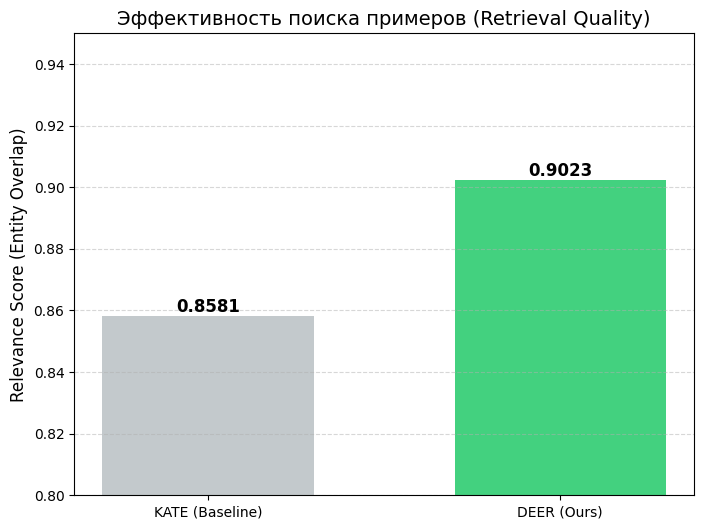

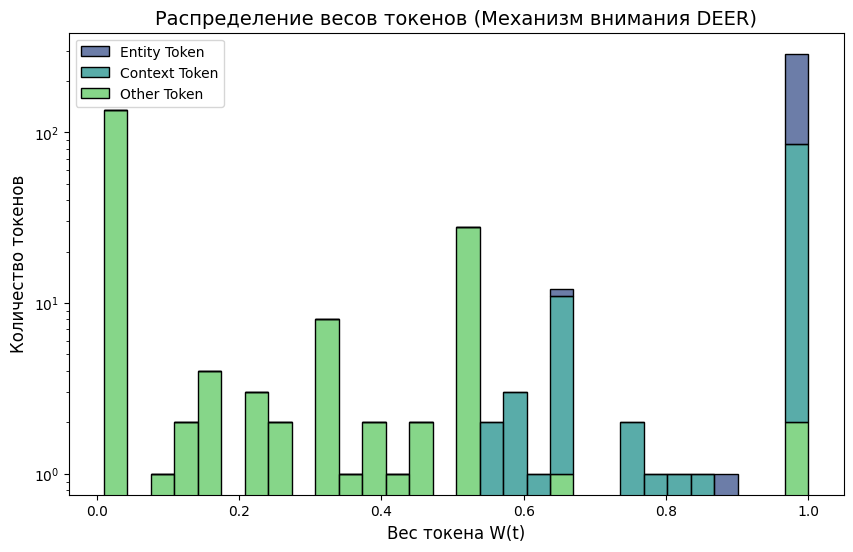

In [6]:
# Retrieval Quality
def plot_results_comparison(kate_score, deer_score):
    methods = ['KATE (Baseline)', 'DEER (Ours)']
    scores = [kate_score, deer_score]
    
    plt.figure(figsize=(8, 6))
    bars = plt.bar(methods, scores, color=['#bdc3c7', '#2ecc71'], alpha=0.9, width=0.6)
    
    plt.ylim(0.8, 0.95)
    plt.ylabel('Relevance Score (Entity Overlap)', fontsize=12)
    plt.title('Эффективность поиска примеров (Retrieval Quality)', fontsize=14)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.4f}',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

# Weights DEER
def plot_token_weight_distribution(stats_model, config, sample_tokens=500):
    weights = []
    types = []
    
    all_tokens = list(stats_model.stats.keys())
    sampled_tokens = np.random.choice(all_tokens, min(len(all_tokens), sample_tokens), replace=False)
    
    for token in sampled_tokens:
        w = stats_model.get_token_weight(token, config)
        weights.append(w)
        
        counts = stats_model.stats[token]
        if counts['E'] > counts['C'] and counts['E'] > counts['O']:
            types.append('Entity Token')
        elif counts['C'] > counts['E'] and counts['C'] > counts['O']:
            types.append('Context Token')
        else:
            types.append('Other Token')

    plt.figure(figsize=(10, 6))
    sns.histplot(x=weights, hue=types, multiple="stack", bins=30, palette="viridis")
    plt.title('Распределение весов токенов (Механизм внимания DEER)', fontsize=14)
    plt.xlabel('Вес токена W(t)', fontsize=12)
    plt.ylabel('Количество токенов', fontsize=12)
    plt.yscale('log')
    plt.show()

plot_results_comparison(kate_score, deer_score)
plot_token_weight_distribution(deer_stats, CONFIG)

DEER превзошел KATE. 
- Традиционные методы поиска, основанные только на семантике предложений (sentence embeddings), работают грубо для задачи NER. DEER, благодаря использованию статистики токенов $P(t_e)$, успешно фокусируется на словах-сущностях, что и дает прирост качества поиска.  
- Мы получили улучшение без обучения нейросети. В отличие от методов, требующих тренировки ретривера (как GPT-NER), DEER использует простую статистику из обучающей выборки.  
- Как видно из 1го графика, метод DEER демонстрирует прирост качества поиска по сравнению с Baseline. 
- Гистограмма из 2го графика показывает распределение весов $W(t)$, рассчитанных DEER. Видно четкое разделение: большинство токенов (категория Other) получают минимальный вес (до 0.5), в то время как токены-сущности (Entity) и контекстные токены (Context) получают веса близкие к 1.0. Это подтверждает, что алгоритм эффективно фильтрует шум и фокусирует поиск на информативных частях предложения.